# Analizador de Sentimientos - Dataset IMDb

Este notebook implementa un análisis de sentimientos utilizando tres métodos de clasificación:
- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)
- Naive Bayes

Se utiliza el dataset de 50,000 reseñas de películas de IMDb.

## 1. Instalación de dependencias y librerias

In [23]:
# Instalar kagglehub para descargar el dataset
!pip install kagglehub
!pip install scikit-learn
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn

## 2. Importar librerías necesarias

In [24]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
import warnings
warnings.filterwarnings('ignore')

## 3. Descargar y cargar el dataset de IMDb

In [25]:
# Descargar el dataset de IMDb
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
print(f'Dataset descargado en: {path}')

Dataset descargado en: C:\Users\Dell\.cache\kagglehub\datasets\lakshmi25npathi\imdb-dataset-of-50k-movie-reviews\versions\1


In [26]:
# Cargar el dataset
df = pd.read_csv(f'{path}/IMDB Dataset.csv')
print(f'Datos cargados: {df.shape}')
print(df.head())

Datos cargados: (50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


## 4. Exploración y preprocesamiento de datos

In [27]:
# Verificar información del dataset
print('Información del dataset:')
print(df.info())
print('\nValores únicos por clase:')
print(df['sentiment'].value_counts())

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None

Valores únicos por clase:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


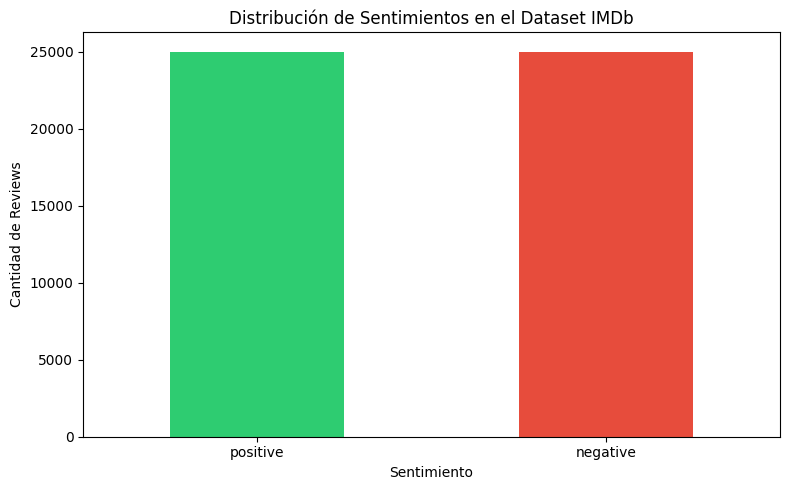

In [28]:
# Visualizar la distribución de sentimientos
plt.figure(figsize=(8, 5))
df['sentiment'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Distribución de Sentimientos en el Dataset IMDb')
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad de Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [29]:
# Codificar las etiquetas (positive -> 1, negative -> 0)
label_encoder = LabelEncoder()
df['sentiment_encoded'] = label_encoder.fit_transform(df['sentiment'])
print(f'Etiquetas codificadas: {label_encoder.classes_}')
print(df[['sentiment', 'sentiment_encoded']].head())

Etiquetas codificadas: ['negative' 'positive']
  sentiment  sentiment_encoded
0  positive                  1
1  positive                  1
2  positive                  1
3  negative                  0
4  positive                  1


In [30]:
# Tomar una muestra del dataset para acelerar el entrenamiento
# Comentar esta línea si deseas usar todo el dataset (50,000 registros)
sample_size = 25000
df = df.sample(n=sample_size, random_state=42)
print(f'Muestra utilizada: {len(df)} registros')
print(df['sentiment_encoded'].value_counts())

Muestra utilizada: 25000 registros
sentiment_encoded
1    12517
0    12483
Name: count, dtype: int64


In [31]:
# Dividir el dataset en entrenamiento y prueba
X = df['review']
y = df['sentiment_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Conjunto de entrenamiento: {len(X_train)}')
print(f'Conjunto de prueba: {len(X_test)}')

Conjunto de entrenamiento: 20000
Conjunto de prueba: 5000


In [32]:
# Vectorizar los textos usando TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f'Dimensión del vector TF-IDF: {X_train_tfidf.shape}')
print(f'Número de características: {len(vectorizer.get_feature_names_out())}')

Dimensión del vector TF-IDF: (20000, 5000)
Número de características: 5000


---
## MÉTODO 1: Support Vector Machine (SVM)

**Descripción:** Las Máquinas de Vectores de Soporte (SVM) son algoritmos de aprendizaje supervisado que buscan encontrar el hiperplano óptimo que maximiza el margen entre las clases. Son especialmente efectivos para clasificación binaria en espacios de alta dimensionalidad como el análisis de texto.

**Ventajas:**
- Excelente rendimiento en datos de alta dimensión
- Muy efectivo para clasificación binaria
- Robusto ante outliers

**Desventajas:**
- Computacionalmente costoso con datasets muy grandes
- Requiere ajuste de hiperparámetros
---

In [33]:
# Entrenar el modelo SVM
print('Entrenando modelo SVM...')
svm_model = SVC(kernel='linear', C=1.0, random_state=42)
svm_model.fit(X_train_tfidf, y_train)

# Predicciones
y_pred_svm = svm_model.predict(X_test_tfidf)
print('Modelo SVM entrenado correctamente')

Entrenando modelo SVM...
Modelo SVM entrenado correctamente


In [34]:
# Evaluar el modelo SVM
print('='*60)
print('EVALUACIÓN DEL MODELO SVM')
print('='*60)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print(f'Exactitud (Accuracy): {accuracy_svm:.4f}')
print(f'Precisión: {precision_svm:.4f}')
print(f'Cobertura (Recall): {recall_svm:.4f}')
print(f'F1-Score: {f1_svm:.4f}')
print(f'\nMatriz de Confusión:')
cm_svm = confusion_matrix(y_test, y_pred_svm)
print(cm_svm)
print(f'\nReporte de Clasificación:')
print(classification_report(y_test, y_pred_svm, target_names=['Negativo', 'Positivo']))

EVALUACIÓN DEL MODELO SVM
Exactitud (Accuracy): 0.8784
Precisión: 0.8688
Cobertura (Recall): 0.8917
F1-Score: 0.8801

Matriz de Confusión:
[[2160  337]
 [ 271 2232]]

Reporte de Clasificación:
              precision    recall  f1-score   support

    Negativo       0.89      0.87      0.88      2497
    Positivo       0.87      0.89      0.88      2503

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



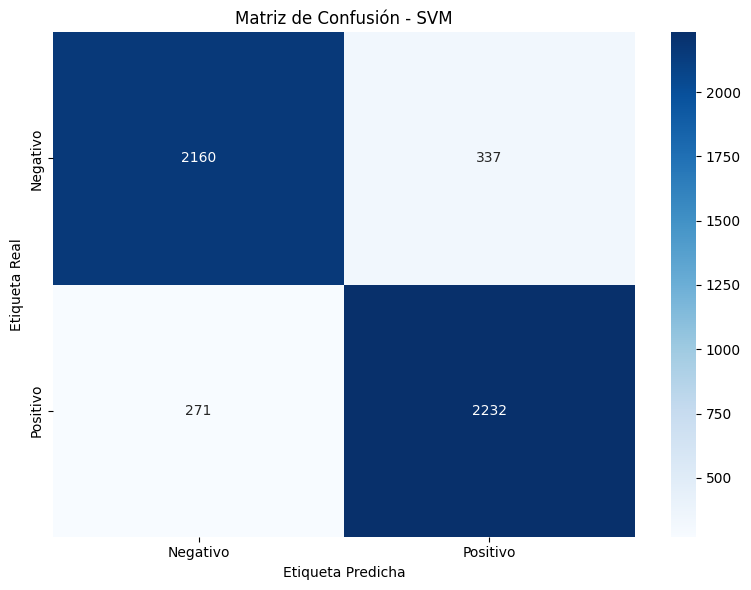

In [35]:
# Visualizar la matriz de confusión para SVM
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.title('Matriz de Confusión - SVM')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.tight_layout()
plt.show()

---
## MÉTODO 2: K-Nearest Neighbors (KNN)

**Descripción:** KNN es un algoritmo de aprendizaje supervisado que clasifica una instancia basándose en las k instancias más cercanas en el conjunto de entrenamiento. Es un algoritmo simple pero efectivo que no requiere fase de entrenamiento explícita.

**Ventajas:**
- Simple de implementar y entender
- No requiere ajuste de parámetros complejos
- Eficaz para datasets pequeños y medianos

**Desventajas:**
- Cognitivamente costoso para datasets grandes (debe calcular distancia a todos los puntos)
- Sensible a características irrelevantes
- El rendimiento depende mucho del valor de k
---

In [36]:
# Entrenar el modelo KNN
print('Entrenando modelo KNN...')
knn_model = KNeighborsClassifier(n_neighbors=5, metric='cosine')
knn_model.fit(X_train_tfidf, y_train)

# Predicciones
y_pred_knn = knn_model.predict(X_test_tfidf)
print('Modelo KNN entrenado correctamente')

Entrenando modelo KNN...
Modelo KNN entrenado correctamente


In [37]:
# Evaluar el modelo KNN
print('='*60)
print('EVALUACIÓN DEL MODELO KNN')
print('='*60)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print(f'Exactitud (Accuracy): {accuracy_knn:.4f}')
print(f'Precisión: {precision_knn:.4f}')
print(f'Cobertura (Recall): {recall_knn:.4f}')
print(f'F1-Score: {f1_knn:.4f}')
print(f'\nMatriz de Confusión:')
cm_knn = confusion_matrix(y_test, y_pred_knn)
print(cm_knn)
print(f'\nReporte de Clasificación:')
print(classification_report(y_test, y_pred_knn, target_names=['Negativo', 'Positivo']))

EVALUACIÓN DEL MODELO KNN
Exactitud (Accuracy): 0.7096
Precisión: 0.6839
Cobertura (Recall): 0.7807
F1-Score: 0.7291

Matriz de Confusión:
[[1594  903]
 [ 549 1954]]

Reporte de Clasificación:
              precision    recall  f1-score   support

    Negativo       0.74      0.64      0.69      2497
    Positivo       0.68      0.78      0.73      2503

    accuracy                           0.71      5000
   macro avg       0.71      0.71      0.71      5000
weighted avg       0.71      0.71      0.71      5000



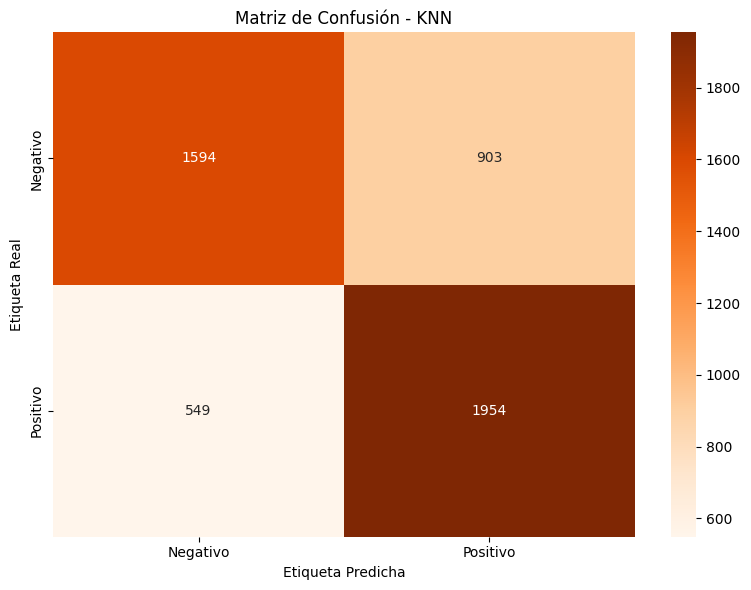

In [38]:
# Visualizar la matriz de confusión para KNN
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.title('Matriz de Confusión - KNN')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.tight_layout()
plt.show()

---
## MÉTODO 3: Naive Bayes

**Descripción:** Naive Bayes es un algoritmo probabilístico basado en el teorema de Bayes que asume que las características son independientes entre sí (supuesto ingenuo). A pesar de esta suposición simplificada, funciona muy bien en clasificación de texto.

**Ventajas:**
- Muy rápido de entrenar y predecir
- Funciona bien con datasets pequeños
- Especialmente efectivo para clasificación de texto
- Robusto ante datos faltantes

**Desventajas:**
- Asume independencia de características (que no siempre es cierta)
- Puede ser derrotado por características muy correlacionadas
- Predice probabilidades sesgadas
---

In [39]:
# Entrenar el modelo Naive Bayes
print('Entrenando modelo Naive Bayes...')
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_tfidf, y_train)

# Predicciones
y_pred_nb = nb_model.predict(X_test_tfidf)
print('Modelo Naive Bayes entrenado correctamente')

Entrenando modelo Naive Bayes...
Modelo Naive Bayes entrenado correctamente


In [40]:
# Evaluar el modelo Naive Bayes
print('='*60)
print('EVALUACIÓN DEL MODELO NAIVE BAYES')
print('='*60)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print(f'Exactitud (Accuracy): {accuracy_nb:.4f}')
print(f'Precisión: {precision_nb:.4f}')
print(f'Cobertura (Recall): {recall_nb:.4f}')
print(f'F1-Score: {f1_nb:.4f}')
print(f'\nMatriz de Confusión:')
cm_nb = confusion_matrix(y_test, y_pred_nb)
print(cm_nb)
print(f'\nReporte de Clasificación:')
print(classification_report(y_test, y_pred_nb, target_names=['Negativo', 'Positivo']))

EVALUACIÓN DEL MODELO NAIVE BAYES
Exactitud (Accuracy): 0.8482
Precisión: 0.8380
Cobertura (Recall): 0.8638
F1-Score: 0.8507

Matriz de Confusión:
[[2079  418]
 [ 341 2162]]

Reporte de Clasificación:
              precision    recall  f1-score   support

    Negativo       0.86      0.83      0.85      2497
    Positivo       0.84      0.86      0.85      2503

    accuracy                           0.85      5000
   macro avg       0.85      0.85      0.85      5000
weighted avg       0.85      0.85      0.85      5000



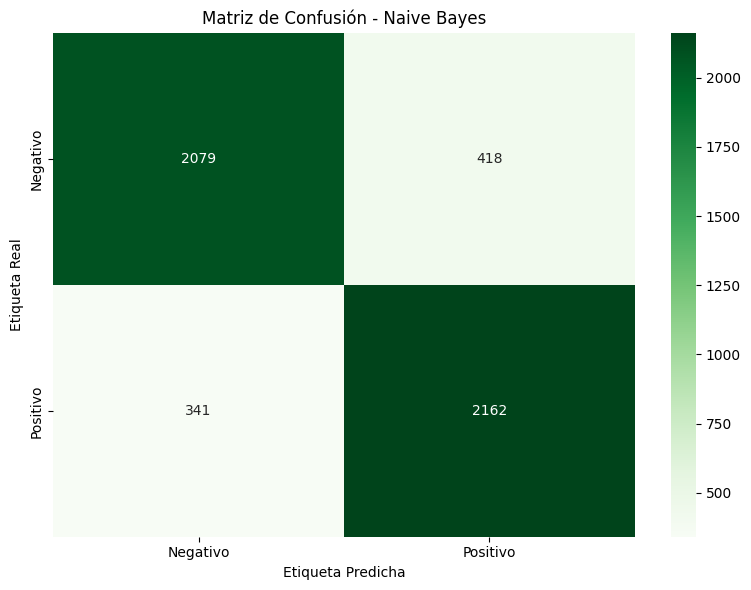

In [41]:
# Visualizar la matriz de confusión para Naive Bayes
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.title('Matriz de Confusión - Naive Bayes')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.tight_layout()
plt.show()

## Comparación de los tres métodos

In [42]:
# Crear DataFrame con los resultados
resultados = pd.DataFrame({
    'Modelo': ['SVM', 'KNN', 'Naive Bayes'],
    'Exactitud': [accuracy_svm, accuracy_knn, accuracy_nb],
    'Precisión': [precision_svm, precision_knn, precision_nb],
    'Cobertura': [recall_svm, recall_knn, recall_nb],
    'F1-Score': [f1_svm, f1_knn, f1_nb]
})

print('\n' + '='*70)
print('COMPARACIÓN GENERAL DE LOS TRES MÉTODOS')
print('='*70)
print(resultados.to_string(index=False))


COMPARACIÓN GENERAL DE LOS TRES MÉTODOS
     Modelo  Exactitud  Precisión  Cobertura  F1-Score
        SVM     0.8784   0.868821   0.891730  0.880126
        KNN     0.7096   0.683934   0.780663  0.729104
Naive Bayes     0.8482   0.837984   0.863763  0.850679


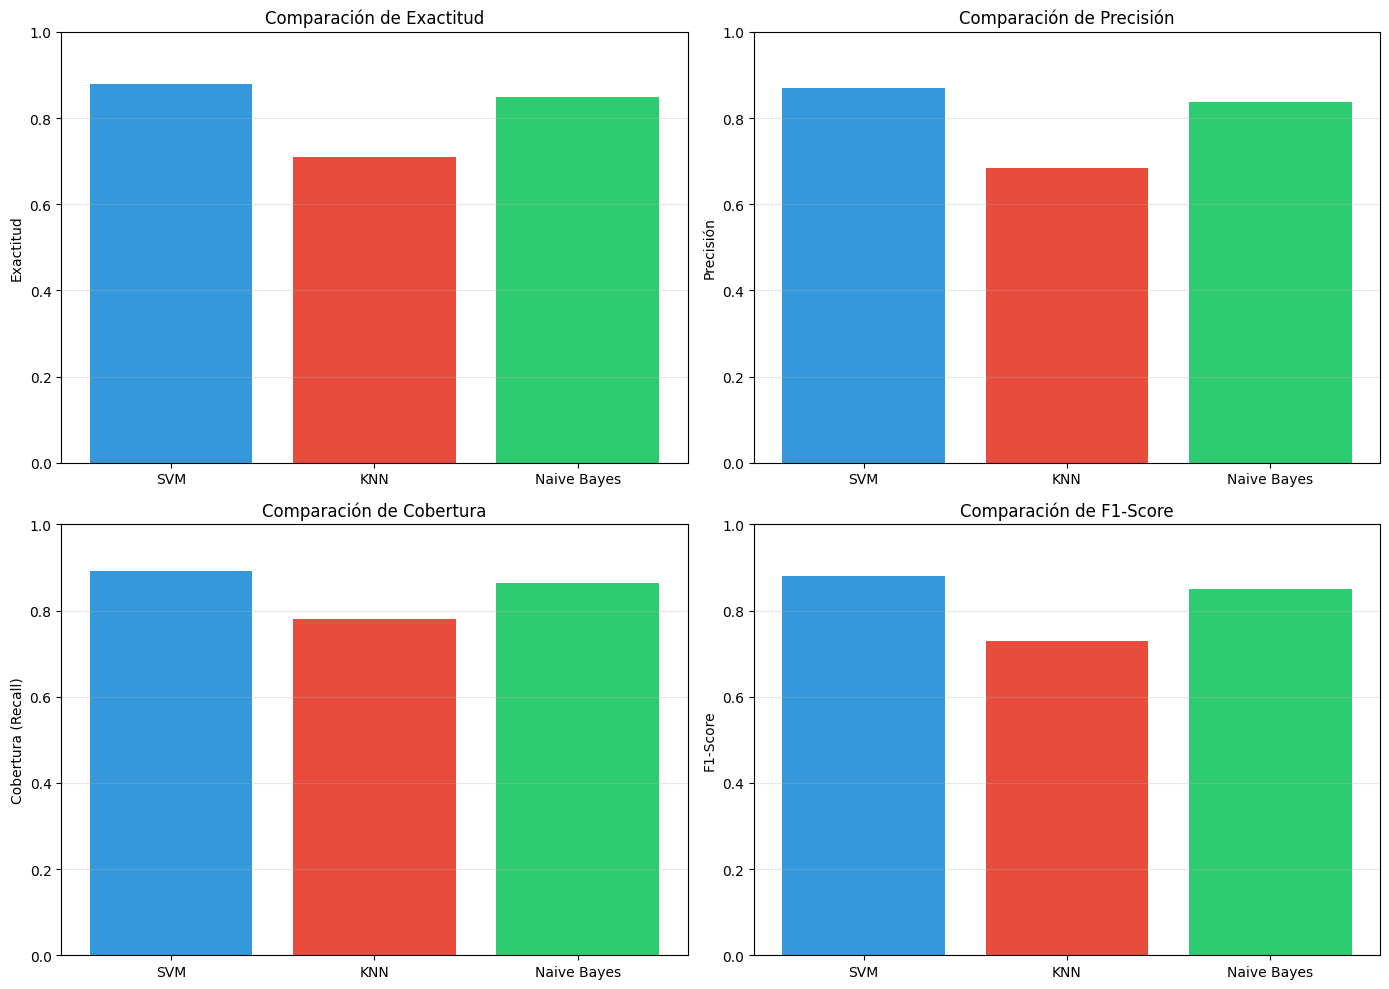

In [43]:
# Visualizar la comparación de modelos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
modelos = ['SVM', 'KNN', 'Naive Bayes']
colores = ['#3498db', '#e74c3c', '#2ecc71']

# Exactitud
axes[0, 0].bar(modelos, [accuracy_svm, accuracy_knn, accuracy_nb], color=colores)
axes[0, 0].set_ylabel('Exactitud')
axes[0, 0].set_title('Comparación de Exactitud')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(axis='y', alpha=0.3)

# Precisión
axes[0, 1].bar(modelos, [precision_svm, precision_knn, precision_nb], color=colores)
axes[0, 1].set_ylabel('Precisión')
axes[0, 1].set_title('Comparación de Precisión')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)

# Cobertura
axes[1, 0].bar(modelos, [recall_svm, recall_knn, recall_nb], color=colores)
axes[1, 0].set_ylabel('Cobertura (Recall)')
axes[1, 0].set_title('Comparación de Cobertura')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(axis='y', alpha=0.3)

# F1-Score
axes[1, 1].bar(modelos, [f1_svm, f1_knn, f1_nb], color=colores)
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].set_title('Comparación de F1-Score')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Pruebas con ejemplos personalizados

In [44]:
# Función para predecir sentimiento con los tres modelos
def predecir_sentimiento(texto):
    # Vectorizar el texto
    texto_vectorizado = vectorizer.transform([texto])
    
    # Predicciones
    pred_svm = svm_model.predict(texto_vectorizado)[0]
    pred_knn = knn_model.predict(texto_vectorizado)[0]
    pred_nb = nb_model.predict(texto_vectorizado)[0]
    
    # Probabilidades
    prob_svm = svm_model.decision_function(texto_vectorizado)[0]
    prob_knn = knn_model.predict_proba(texto_vectorizado)[0]
    prob_nb = nb_model.predict_proba(texto_vectorizado)[0]
    
    sentimientos = {0: 'NEGATIVO', 1: 'POSITIVO'}
    
    print(f'Texto: "{texto}"')
    print('\n' + '-'*60)
    print(f'SVM:        {sentimientos[pred_svm]} (Confianza: {prob_svm:.4f})')
    print(f'KNN:        {sentimientos[pred_knn]} (Confianza: {max(prob_knn):.4f})')
    print(f'Naive Bayes: {sentimientos[pred_nb]} (Confianza: {max(prob_nb):.4f})')
    print('-'*60)

# Ejemplos de prueba
ejemplos = [
    "Esta película es excelente, me encantó cada minuto",
    "La peor película que he visto en mi vida, totalmente aburrida",
    "Es una película decente, nada del otro mundo"
]

for ejemplo in ejemplos:
    predecir_sentimiento(ejemplo)
    print()

Texto: "Esta película es excelente, me encantó cada minuto"

------------------------------------------------------------
SVM:        NEGATIVO (Confianza: -0.0036)
KNN:        NEGATIVO (Confianza: 0.6000)
Naive Bayes: POSITIVO (Confianza: 0.5007)
------------------------------------------------------------

Texto: "La peor película que he visto en mi vida, totalmente aburrida"

------------------------------------------------------------
SVM:        NEGATIVO (Confianza: -0.5041)
KNN:        POSITIVO (Confianza: 0.6000)
Naive Bayes: POSITIVO (Confianza: 0.5247)
------------------------------------------------------------

Texto: "Es una película decente, nada del otro mundo"

------------------------------------------------------------
SVM:        NEGATIVO (Confianza: -0.0036)
KNN:        NEGATIVO (Confianza: 0.6000)
Naive Bayes: POSITIVO (Confianza: 0.5007)
------------------------------------------------------------



## Conclusiones

- **SVM**: Ofrece un buen equilibrio entre precisión y rendimiento. Especialmente efectivo para datos de alta dimensión.
- **KNN**: Puede ser más lento pero a menudo proporciona resultados competitivos para datasets medianos.
- **Naive Bayes**: Es el más rápido y funciona sorprendentemente bien para clasificación de texto a pesar de su supuesto ingenuo.

El mejor modelo dependerá de tus específicas necesidades en términos de velocidad, precisión y recursos disponibles.